Connection a Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Decompression du dataset

In [5]:
!unzip -q /content/drive/MyDrive/dataset.yolov8.zip -d /content/drive/MyDrive/dataset.yolov8
!ls /content/drive/MyDrive/dataset.yolov8/

data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


In [3]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 31.2 MB/s eta 0:00:00


Entrainement du modele

In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')
dataset_yaml_path = '/content/drive/MyDrive/dataset.yolov8/data.yaml'
results = model.train(
    data=dataset_yaml_path,
    epochs=100,
    imgsz=640,
    batch=16,
    name='drowsiness_yolo',
    patience=15,
    # device=0  # GPU
)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.89 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/dataset.yolov8/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_

In [ ]:
print(" ÉVALUATION SUR L'ENSEMBLE DE TEST ")
metrics_test = model.val(split='test')
print(f"mAP@50 sur le test : {metrics_test.box.map50:.3f}")

# Export TFLite INT8
model.export(format='tflite', imgsz=640, int8=True, data=dataset_yaml_path)

In [ ]:
from ultralytics import YOLO

# Chemin vers le modèle .tflite exporté
tflite_model_path = '/content/runs/detect/drowsiness_yolo/weights/best_saved_model/best_int8.tflite'

dataset_yaml_path = '/content/drive/MyDrive/dataset.yolov8/data.yaml'

print(" Validation du modèle TFLite INT8 ")
yolo_model = YOLO(tflite_model_path)
yolo_model.val(imgsz=224, data=dataset_yaml_path, split='test')

print("La validation du modèle .tflite est terminée. Veuillez consulter les résultats ci-dessus.")

In [ ]:
# Téléchargement du modèle TFLite
from google.colab import files
files.download('/content/runs/detect/drowsiness_yolo/weights/best_saved_model/best_int8.tflite')

!zip -r /content/drowsiness_yolo_run.zip /content/runs/detect/drowsiness_yolo
files.download('/content/drowsiness_yolo_run.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  adding: content/runs/detect/drowsiness_yolo/ (stored 0%)
  adding: content/runs/detect/drowsiness_yolo/args.yaml (deflated 53%)
  adding: content/runs/detect/drowsiness_yolo/BoxPR_curve.png (deflated 20%)
  adding: content/runs/detect/drowsiness_yolo/results.png (deflated 7%)
  adding: content/runs/detect/drowsiness_yolo/train_batch2.jpg (deflated 2%)
  adding: content/runs/detect/drowsiness_yolo/BoxR_curve.png (deflated 12%)
  adding: content/runs/detect/drowsiness_yolo/val_batch0_labels.jpg (deflated 18%)
  adding: content/runs/detect/drowsiness_yolo/val_batch1_pred.jpg (deflated 14%)
  adding: content/runs/detect/drowsiness_yolo/BoxP_curve.png (deflated 13%)
  adding: content/runs/detect/drowsiness_yolo/train_batch1.jpg (deflated 4%)
  adding: content/runs/detect/drowsiness_yolo/confusion_matrix.png (deflated 29%)
  adding: content/runs/detect/drowsiness_yolo/labels.jpg (deflated 41%)
  adding: content/runs/detect/drowsiness_yolo/weights/ (stored 0%)
  adding: content/runs/detect/

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Verification du modele obtenu**

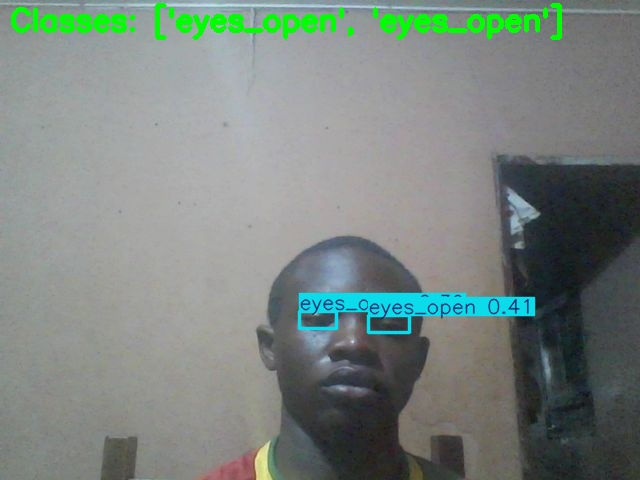


--- Arrêt de la capture vidéo. ---


In [ ]:
import os
from ultralytics import YOLO
from base64 import b64decode, b64encode
import cv2
import numpy as np
from IPython.display import display, Javascript, Image, clear_output
from google.colab.output import eval_js
import time

model_path = '/content/runs/detect/drowsiness_yolo/weights/best.pt'
# model_path = '/content/yolov8n.pt'
model_realtime = YOLO(model_path)

# --- Fonctions utilitaires pour la conversion d'images ---
def b64_to_jpeg(b64_string):
    img_bytes = b64decode(b64_string.split(',')[1])
    np_arr = np.frombuffer(img_bytes, np.uint8)
    img = cv2.imdecode(np_arr, cv2.IMREAD_COLOR)
    return img

def jpeg_to_b64(image):
    ret, jpeg = cv2.imencode('.jpg', image)
    return b64encode(jpeg.tobytes()).decode('utf-8')

# Helper to create a blank black image for initial display
def create_empty_image(width=640, height=480):
    black_image = np.zeros((height, width, 3), dtype=np.uint8)
    return jpeg_to_b64(black_image)

# --- JavaScript pour la capture d'une seule image de la webcam ---
def get_frame_from_webcam_js():
  js = Javascript('''
    (async function() {
      const video = document.createElement('video');
      video.style.display = 'none'; // Cacher l'élément vidéo
      document.body.appendChild(video);
      const stream = await navigator.mediaDevices.getUserMedia({video: true});
      video.srcObject = stream;
      await video.play();

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      const ctx = canvas.getContext('2d');

      // Attendre un peu pour que la vidéo s'initialise et pour une image stable
      await new Promise(resolve => setTimeout(resolve, 500));

      ctx.drawImage(video, 0, 0, canvas.width, canvas.height);
      const dataUrl = canvas.toDataURL('image/jpeg', 0.8);

      stream.getTracks().forEach(track => track.stop()); // Arrêter la webcam
      video.remove();
      canvas.remove();
      return dataUrl;
    })(); // Appeler et exécuter immédiatement la fonction async
  ''')
  return js

# --- Boucle de capture et de prédiction en temps réel ---
try:
  # Initialize output_image for display
  output_image = display(Image(data=b64decode(create_empty_image())), display_id=True)

  while True:
      b64_frame_js = eval_js(get_frame_from_webcam_js().data)
      if b64_frame_js and b64_frame_js != 'undefined':
          frame = b64_to_jpeg(b64_frame_js)

          results = model_realtime(frame, stream=True, verbose=False)
          annotated_frame = frame.copy()
          classes_detected = []

          for r in results:
              annotated_frame = r.plot()
              if r.boxes is not None:
                  for box in r.boxes:
                      cls_id = int(box.cls[0])
                      classes_detected.append(cls_id)

          # Affichage des classes détectées
          class_names = [model_realtime.names[c] for c in classes_detected]
          cv2.putText(annotated_frame, f"Classes: {class_names}", (10, 30),
                      cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 3) # Increased size and thickness

          # Mise à jour de l'affichage
          img_str_annotated = jpeg_to_b64(annotated_frame)
          output_image.update(Image(data=b64decode(img_str_annotated)))
      else:
          time.sleep(0.1)
except KeyboardInterrupt:
    print("\n--- Arrêt de la capture vidéo. ---")
except Exception as e:
    print(f"\nUne erreur est survenue : {e}")

clear_output(wait=True) # Clear the final output (image, etc.)

### Prédiction sur une Image Importée

Vous pouvez également télécharger une image depuis votre système local et la faire analyser par le modèle YOLOv8 pour détecter la somnolence.

In [ ]:
from google.colab import files
from IPython.display import Image
from base64 import b64decode
import cv2
import numpy as np

# Télécharger une image depuis votre système local
uploaded = files.upload()

for filename in uploaded.keys():
    # Lire l'image téléchargée
    img_np = cv2.imdecode(np.frombuffer(uploaded[filename], np.uint8), cv2.IMREAD_COLOR)

    # Effectuer la prédiction
    results_image = model_realtime(img_np, verbose=False)

    # Annoter l'image
    annotated_image = img_np.copy()
    classes_detected = []
    for r in results_image:
        annotated_image = r.plot()
        if r.boxes is not None:
            for box in r.boxes:
                cls_id = int(box.cls[0])
                classes_detected.append(cls_id)

    # Affichage des classes détectées sur l'image
    class_names = [model_realtime.names[c] for c in classes_detected]
    cv2.putText(annotated_image, f"Classes: {class_names}", (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

    # Convertir l'image annotée en base64 string
    img_str_annotated = jpeg_to_b64(annotated_image)

    # Afficher l'image annotée en décodant la base64 string en bytes
    display(Image(data=b64decode(img_str_annotated)))

KeyboardInterrupt: 